<!-- Trabalho Desenvolvido no Curso da Data Science Academy - www.datascienceacademy.com.br -->
# <font color='blue'>Data Science Academy</font>
# <font color='blue'>Fundamentos de Linguagem Python - Do Básico a Aplicações de IA</font>
# <font color='blue'>Limpeza, Transformação e Análise de Dados com Pandas </font>

## O Que é e Quando Usar o Pandas?

Leia o manual em pdf no Capítulo 9 do Curso.

In [1]:
!pip install -q -U watermark


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
%reload_ext watermark
%watermark -a "Nemarvin"

Author: Nemarvin



In [6]:
%watermark --iversions

matplotlib: 3.10.9
numpy     : 2.4.4
pandas    : 3.0.2



## 1- Pandas e Estruturas de Dados - Series e DataFrame

Vamos começar criando as estruturas de dados fundamentais: Series e DataFrame.

No Pandas, uma Series (uma série) é uma estrutura unidimensional, parecida com uma coluna de uma tabela: contém uma sequência de valores com um índice associado. Já um DataFrame é uma estrutura bidimensional, semelhante a uma planilha, tabela ou matriz, formada por várias colunas (que são, internamente, Series alinhadas pelo mesmo índice).

In [7]:
# Criando uma Series (uma única coluna)
s = pd.Series([10, 20, 30, 40, 50], name = 'Valores')

In [8]:
type(s)

pandas.Series

In [11]:
print("\n--- Exemplo de Series ---\n")
print(s)
print("\n")


--- Exemplo de Series ---

0    10
1    20
2    30
3    40
4    50
Name: Valores, dtype: int64




In [12]:
# Criamos um dicionário em Python (observe que alguns valores estão nulos representados como None)
dados = {
    'Nome': ['Ana', 'Bruno', 'Fabiana', 'Ronaldo', 'Eliana', 'Matias'],
    'Idade': [28, 34, 29, 17, None, 78],
    'Cidade': ['Blumenau', 'São Paulo', 'Blumenau', 'São Paulo', 'Salvador', 'São Paulo'],
    'Salário': [None, 7500, 6200, 9300, 8100, 15400]
}

In [13]:
type(dados)

dict

In [14]:
print(dados)

{'Nome': ['Ana', 'Bruno', 'Fabiana', 'Ronaldo', 'Eliana', 'Matias'], 'Idade': [28, 34, 29, 17, None, 78], 'Cidade': ['Blumenau', 'São Paulo', 'Blumenau', 'São Paulo', 'Salvador', 'São Paulo'], 'Salário': [None, 7500, 6200, 9300, 8100, 15400]}


In [15]:
# Convertemos o dicionário em um dataframe do pandas
df_dsa = pd.DataFrame(dados)

In [16]:
type(df_dsa)

pandas.DataFrame

In [17]:
print("\n--- Exemplo de DataFrame ---\n")
print(df_dsa)


--- Exemplo de DataFrame ---

      Nome  Idade     Cidade  Salário
0      Ana   28.0   Blumenau      NaN
1    Bruno   34.0  São Paulo   7500.0
2  Fabiana   29.0   Blumenau   6200.0
3  Ronaldo   17.0  São Paulo   9300.0
4   Eliana    NaN   Salvador   8100.0
5   Matias   78.0  São Paulo  15400.0


## 2- Leitura e Escrita de Dados no Formato CSV

Pandas torna muito fácil salvar seu DataFrame em um arquivo CSV e carregá-lo de volta.

In [18]:
# Escrevendo (salvando) o DataFrame em um arquivo CSV
# index=False evita que o índice do DataFrame seja salvo como uma coluna no CSV
df_dsa.to_csv('dados_funcionarios_sem_indice.csv', index = False, encoding = 'utf-8')

In [19]:
# Escrevendo (salvando) o DataFrame em um arquivo CSV
# index=True (valor padrão) inclui o índice do DataFrame como uma coluna no CSV
df_dsa.to_csv('dados_funcionarios_com_indice.csv', encoding = 'utf-8')

In [21]:
# Lendo dados de um arquivo CSV para um novo DataFrame
df_dsa_1 = pd.read_csv('dados_funcionarios_sem_indice.csv')

In [22]:
# Visualizando as primeiras linhas
df_dsa_1.head(6)

,Nome,Idade,Cidade,Salário
0,Ana,28.0,Blumenau,NaN
1,Bruno,34.0,São Paulo,7500.0
2,Fabiana,29.0,Blumenau,6200.0
3,Ronaldo,17.0,São Paulo,9300.0
4,Eliana,NaN,Salvador,8100.0
5,Matias,78.0,São Paulo,15400.0


In [23]:
# Lendo dados de um arquivo CSV para um novo DataFrame
df_dsa_2 = pd.read_csv('dados_funcionarios_com_indice.csv')

In [24]:
# Visualizando as primeiras linhas
df_dsa_2.head(6)

,Unnamed: 0,Nome,Idade,Cidade,Salário
0,0,Ana,28.0,Blumenau,NaN
1,1,Bruno,34.0,São Paulo,7500.0
2,2,Fabiana,29.0,Blumenau,6200.0
3,3,Ronaldo,17.0,São Paulo,9300.0
4,4,Eliana,NaN,Salvador,8100.0
5,5,Matias,78.0,São Paulo,15400.0


In [25]:
# Deletando a coluna de índice 0
df_dsa_2 = df_dsa_2.drop(df_dsa_2.columns[0], axis = 1)

In [26]:
# Visualizando as primeiras linhas
df_dsa_2.head(6)

,Nome,Idade,Cidade,Salário
0,Ana,28.0,Blumenau,NaN
1,Bruno,34.0,São Paulo,7500.0
2,Fabiana,29.0,Blumenau,6200.0
3,Ronaldo,17.0,São Paulo,9300.0
4,Eliana,NaN,Salvador,8100.0
5,Matias,78.0,São Paulo,15400.0


## 3. Seleção e Indexação com Pandas

Existem várias maneiras de selecionar dados de um DataFrame. As mais comuns são loc (baseado em rótulo) e iloc (baseado em posição/índice numérico).

In [27]:
# Visualizando as primeiras linhas
df_dsa.head(6)

,Nome,Idade,Cidade,Salário
0,Ana,28.0,Blumenau,NaN
1,Bruno,34.0,São Paulo,7500.0
2,Fabiana,29.0,Blumenau,6200.0
3,Ronaldo,17.0,São Paulo,9300.0
4,Eliana,NaN,Salvador,8100.0
5,Matias,78.0,São Paulo,15400.0


In [28]:
# Selecionando uma única coluna (retorna uma Series)
nomes = df_dsa['Nome']
print("\n--- Selecionando a coluna 'Nome' ---\n")
print(nomes)
print("\n")


--- Selecionando a coluna 'Nome' ---

0        Ana
1      Bruno
2    Fabiana
3    Ronaldo
4     Eliana
5     Matias
Name: Nome, dtype: str




In [29]:
type(nomes)

pandas.Series

In [30]:
# Visualizando as primeiras linhas
df_dsa.head(6)

,Nome,Idade,Cidade,Salário
0,Ana,28.0,Blumenau,NaN
1,Bruno,34.0,São Paulo,7500.0
2,Fabiana,29.0,Blumenau,6200.0
3,Ronaldo,17.0,São Paulo,9300.0
4,Eliana,NaN,Salvador,8100.0
5,Matias,78.0,São Paulo,15400.0


In [31]:
# Selecionando múltiplas colunas (retorna um DataFrame)
info_pessoal = df_dsa[['Nome', 'Idade']]
print("\n--- Selecionando as colunas 'Nome' e 'Idade' ---\n")
print(info_pessoal)
print("\n")


--- Selecionando as colunas 'Nome' e 'Idade' ---

      Nome  Idade
0      Ana   28.0
1    Bruno   34.0
2  Fabiana   29.0
3  Ronaldo   17.0
4   Eliana    NaN
5   Matias   78.0




In [32]:
type(info_pessoal)

pandas.DataFrame

In [33]:
# Visualizando as primeiras linhas
df_dsa.head(6)

,Nome,Idade,Cidade,Salário
0,Ana,28.0,Blumenau,NaN
1,Bruno,34.0,São Paulo,7500.0
2,Fabiana,29.0,Blumenau,6200.0
3,Ronaldo,17.0,São Paulo,9300.0
4,Eliana,NaN,Salvador,8100.0
5,Matias,78.0,São Paulo,15400.0


In [35]:
# Usando .loc para selecionar pela linha (rótulo/índice 1) e coluna ('Nome')
nome = df_dsa.loc[1, 'Nome']
print(f"\n--- Selecionando com .loc[1, 'Nome'] ---\n{nome}\n")


--- Selecionando com .loc[1, 'Nome'] ---
Bruno



In [37]:
# Visualizando as primeiras linhas
df_dsa.head(6)

,Nome,Idade,Cidade,Salário
0,Ana,28.0,Blumenau,NaN
1,Bruno,34.0,São Paulo,7500.0
2,Fabiana,29.0,Blumenau,6200.0
3,Ronaldo,17.0,São Paulo,9300.0
4,Eliana,NaN,Salvador,8100.0
5,Matias,78.0,São Paulo,15400.0


In [38]:
# Usando .iloc para selecionar pela posição da linha (linha 2) e da coluna (coluna 3)
salario_fabiana = df_dsa.iloc[2, 3]
print(f"\n--- Selecionando com .iloc[2, 3] ---\n{salario_fabiana}\n")


--- Selecionando com .iloc[2, 3] ---
6200.0



In [39]:
# Visualizando as primeiras linhas
df_dsa.head(6)

,Nome,Idade,Cidade,Salário
0,Ana,28.0,Blumenau,NaN
1,Bruno,34.0,São Paulo,7500.0
2,Fabiana,29.0,Blumenau,6200.0
3,Ronaldo,17.0,São Paulo,9300.0
4,Eliana,NaN,Salvador,8100.0
5,Matias,78.0,São Paulo,15400.0


In [41]:
# Selecionando um intervalo de linhas
primeiras_tres_linhas = df_dsa.loc[0:2] # O final (2) é inclusivo com .loc
print("\n--- Selecionando as 3 primeiras linhas com .loc ---\n")
print(primeiras_tres_linhas)


--- Selecionando as 3 primeiras linhas com .loc ---

      Nome  Idade     Cidade  Salário
0      Ana   28.0   Blumenau      NaN
1    Bruno   34.0  São Paulo   7500.0
2  Fabiana   29.0   Blumenau   6200.0


## 4. Filtragem de Dados com Pandas

Você pode filtrar linhas com base em condições lógicas, de forma muito intuitiva, bem como usar colunas como índice.

In [42]:
# Visualizando as primeiras linhas
df_dsa.head(6)

,Nome,Idade,Cidade,Salário
0,Ana,28.0,Blumenau,NaN
1,Bruno,34.0,São Paulo,7500.0
2,Fabiana,29.0,Blumenau,6200.0
3,Ronaldo,17.0,São Paulo,9300.0
4,Eliana,NaN,Salvador,8100.0
5,Matias,78.0,São Paulo,15400.0


In [43]:
# Convertendo a coluna zero em índice
df_dsa = df_dsa.set_index(df_dsa.columns[0])

In [44]:
# Visualizando as primeiras linhas
df_dsa.head(6)

,Idade,Cidade,Salário
Nome,,,
Ana,28.0,Blumenau,NaN
Bruno,34.0,São Paulo,7500.0
Fabiana,29.0,Blumenau,6200.0
Ronaldo,17.0,São Paulo,9300.0
Eliana,NaN,Salvador,8100.0
Matias,78.0,São Paulo,15400.0


In [45]:
# Filtramos usando label do índice (linha) e da coluna
df_dsa.loc["Fabiana", "Salário"]

np.float64(6200.0)

In [46]:
# Podemos aplicar o filtro de forma que retorne um dataframe. Observe a diferença sutil na sintaxe.
df_dsa.loc[["Fabiana"], ["Salário"]]

,Salário
Nome,
Fabiana,6200.0


In [39]:
# Reset para retornar o índice ao padrão do Pandas
df_dsa = df_dsa.reset_index()

In [47]:
# Visualizando as primeiras linhas
df_dsa.head(6)

,Idade,Cidade,Salário
Nome,,,
Ana,28.0,Blumenau,NaN
Bruno,34.0,São Paulo,7500.0
Fabiana,29.0,Blumenau,6200.0
Ronaldo,17.0,São Paulo,9300.0
Eliana,NaN,Salvador,8100.0
Matias,78.0,São Paulo,15400.0


In [48]:
# Filtrando funcionários com idade superior a 30 anos
mais_de_30 = df_dsa[df_dsa['Idade'] > 30]
print("\n--- Funcionários com mais de 30 anos ---\n")
print(mais_de_30)
print("\n")


--- Funcionários com mais de 30 anos ---

        Idade     Cidade  Salário
Nome                             
Bruno    34.0  São Paulo   7500.0
Matias   78.0  São Paulo  15400.0




In [51]:
# Filtrando funcionários de São Paulo com salário acima de 6000
sp_salario_alto = df_dsa[(df_dsa['Cidade'] == 'São Paulo') & (df_dsa['Salário'] > 6000)]
print("\n--- Funcionários de São Paulo com salário > 6000 ---\n")
print(sp_salario_alto)


--- Funcionários de São Paulo com salário > 6000 ---

         Idade     Cidade  Salário
Nome                              
Bruno     34.0  São Paulo   7500.0
Ronaldo   17.0  São Paulo   9300.0
Matias    78.0  São Paulo  15400.0


In [52]:
# Verificamos quais células têm valores nulos
df_dsa.isnull()

,Idade,Cidade,Salário
Nome,,,
Ana,False,False,True
Bruno,False,False,False
Fabiana,False,False,False
Ronaldo,False,False,False
Eliana,True,False,False
Matias,False,False,False


In [53]:
# Verificamos se há qualquer valor nulo em cada coluna
df_dsa.isnull().any()

Idade       True
Cidade     False
Salário     True
dtype: bool

In [54]:
# Retorna apenas as colunas que possuem pelo menos um valor nulo
df_dsa_colunas_com_nulos = df_dsa.loc[:, df_dsa.isnull().any()]

In [55]:
df_dsa_colunas_com_nulos.head()

,Idade,Salário
Nome,,
Ana,28.0,NaN
Bruno,34.0,7500.0
Fabiana,29.0,6200.0
Ronaldo,17.0,9300.0
Eliana,NaN,8100.0


In [56]:
# Retorna apenas linhas com valores nulos
df_dsa_linhas_com_nulos = df_dsa[df_dsa.isnull().any(axis = 1)]

In [57]:
df_dsa_linhas_com_nulos.head()

,Idade,Cidade,Salário
Nome,,,
Ana,28.0,Blumenau,NaN
Eliana,NaN,Salvador,8100.0


In [58]:
# Podemos ainda filtrar pela coluna e então verificar se há valores nulos
linhas_com_nulos_idade = df_dsa[df_dsa["Idade"].isnull()]

In [59]:
linhas_com_nulos_idade.head()

,Idade,Cidade,Salário
Nome,,,
Eliana,NaN,Salvador,8100.0


## 5. Inspeção de DataFrames do Pandas

Podemos inspecionar e resumir o dataframe de várias formas.

In [61]:
# Mostra o número de linhas e colunas (formato)
print(f"\n--- Formato do DataFrame (.shape) ---\n{df_dsa.shape}")


--- Formato do DataFrame (.shape) ---
(6, 3)


In [65]:
# Mostra as 3 primeiras linhas do DataFrame
print("\n--- As 3 primeiras linhas (.head(3)) ---\n")
print(df_dsa.head(3))
print("\n")


--- As 3 primeiras linhas (.head(3)) ---

         Idade     Cidade  Salário
Nome                              
Ana       28.0   Blumenau      NaN
Bruno     34.0  São Paulo   7500.0
Fabiana   29.0   Blumenau   6200.0




In [66]:
# Mostra as 2 últimas linhas do DataFrame
print("\n--- As 2 últimas linhas (.tail(2)) ---\n")
print(df_dsa.tail(2))
print("\n")


--- As 2 últimas linhas (.tail(2)) ---

        Idade     Cidade  Salário
Nome                             
Eliana    NaN   Salvador   8100.0
Matias   78.0  São Paulo  15400.0




In [67]:
# Fornece um resumo conciso do DataFrame (tipos de dados, valores não nulos, etc.)
# Observe a contagem de valores
print("\n--- Informações gerais (.info()) ---\n")
df_dsa.info()
print("\n")


--- Informações gerais (.info()) ---

<class 'pandas.DataFrame'>
Index: 6 entries, Ana to Matias
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Idade    5 non-null      float64
 1   Cidade   6 non-null      str    
 2   Salário  5 non-null      float64
dtypes: float64(2), str(1)
memory usage: 452.0 bytes




In [68]:
# Gera estatísticas descritivas das colunas numéricas
print("\n--- Estatísticas descritivas (.describe()) ---\n")
print(df_dsa.describe())
print("\n")


--- Estatísticas descritivas (.describe()) ---

           Idade       Salário
count   5.000000      5.000000
mean   37.200000   9300.000000
std    23.636836   3588.175024
min    17.000000   6200.000000
25%    28.000000   7500.000000
50%    29.000000   8100.000000
75%    34.000000   9300.000000
max    78.000000  15400.000000




In [69]:
print("\n--- Estatísticas descritivas (numéricas e objetos) ---\n")
print(df_dsa.describe(include = 'all'))  # inclui números, objetos e categorias


--- Estatísticas descritivas (numéricas e objetos) ---

            Idade     Cidade       Salário
count    5.000000          6      5.000000
unique        NaN          3           NaN
top           NaN  São Paulo           NaN
freq          NaN          3           NaN
mean    37.200000        NaN   9300.000000
std     23.636836        NaN   3588.175024
min     17.000000        NaN   6200.000000
25%     28.000000        NaN   7500.000000
50%     29.000000        NaN   8100.000000
75%     34.000000        NaN   9300.000000
max     78.000000        NaN  15400.000000


In [72]:
df_dsa.describe(include = [object])   # só colunas do tipo object

/tmp/ipykernel_9388/246400873.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_dsa.describe(include = [object])   # só colunas do tipo object


,Cidade
count,6
unique,3
top,São Paulo
freq,3


In [73]:
df_dsa.describe(include = [np.number])  # só colunas numéricas (comportamento padrão)

,Idade,Salário
count,5.000000,5.000000
mean,37.200000,9300.000000
std,23.636836,3588.175024
min,17.000000,6200.000000
25%,28.000000,7500.000000
50%,29.000000,8100.000000
75%,34.000000,9300.000000
max,78.000000,15400.000000


## 6. Operações e Transformações de Dados com Pandas

Você pode facilmente criar novas colunas a partir de outras ou aplicar funções para modificar os dados. Fazemos isso com frequência em tarefas de engenharia de atributos em projetos de Ciência de Dados.

In [74]:
df_dsa.head(6)

,Idade,Cidade,Salário
Nome,,,
Ana,28.0,Blumenau,NaN
Bruno,34.0,São Paulo,7500.0
Fabiana,29.0,Blumenau,6200.0
Ronaldo,17.0,São Paulo,9300.0
Eliana,NaN,Salvador,8100.0
Matias,78.0,São Paulo,15400.0


In [75]:
# Criando uma nova coluna 'Salário Anual'
df_dsa['Salário Anual'] = df_dsa['Salário'] * 12
print("\n--- DataFrame com a nova coluna 'Salário Anual' ---\n")
print(df_dsa)
print("\n")


--- DataFrame com a nova coluna 'Salário Anual' ---

         Idade     Cidade  Salário  Salário Anual
Nome                                             
Ana       28.0   Blumenau      NaN            NaN
Bruno     34.0  São Paulo   7500.0        90000.0
Fabiana   29.0   Blumenau   6200.0        74400.0
Ronaldo   17.0  São Paulo   9300.0       111600.0
Eliana     NaN   Salvador   8100.0        97200.0
Matias    78.0  São Paulo  15400.0       184800.0




In [76]:
# Aplicando uma função para criar uma coluna de bônus
# A função lambda aplica a operação para cada valor na coluna 'Salário'
df_dsa['Bônus'] = df_dsa['Salário'].apply(lambda x: x * 0.10 if x > 7000 else x * 0.05)
print("\n--- DataFrame com a nova coluna 'Bônus' ---\n")
print(df_dsa)


--- DataFrame com a nova coluna 'Bônus' ---

         Idade     Cidade  Salário  Salário Anual   Bônus
Nome                                                     
Ana       28.0   Blumenau      NaN            NaN     NaN
Bruno     34.0  São Paulo   7500.0        90000.0   750.0
Fabiana   29.0   Blumenau   6200.0        74400.0   310.0
Ronaldo   17.0  São Paulo   9300.0       111600.0   930.0
Eliana     NaN   Salvador   8100.0        97200.0   810.0
Matias    78.0  São Paulo  15400.0       184800.0  1540.0


Vamos criar uma coluna de faixa etária.

In [77]:
# Define as condições (vamos criar o que chamamos de máscara)
condicoes = [
    df_dsa['Idade'] < 18,
    (df_dsa['Idade'] >= 18) & (df_dsa['Idade'] <= 30),
    (df_dsa['Idade'] > 30) & (df_dsa['Idade'] <= 60),
    df_dsa['Idade'] > 60
]

In [78]:
print(condicoes)

[Nome
Ana        False
Bruno      False
Fabiana    False
Ronaldo     True
Eliana     False
Matias     False
Name: Idade, dtype: bool, Nome
Ana         True
Bruno      False
Fabiana     True
Ronaldo    False
Eliana     False
Matias     False
Name: Idade, dtype: bool, Nome
Ana        False
Bruno       True
Fabiana    False
Ronaldo    False
Eliana     False
Matias     False
Name: Idade, dtype: bool, Nome
Ana        False
Bruno      False
Fabiana    False
Ronaldo    False
Eliana     False
Matias      True
Name: Idade, dtype: bool]


In [80]:
# Define os rótulos correspondentes
faixas = ['Menor de idade', 'Jovem', 'Adulto', 'Idoso']

In [81]:
# Cria a nova coluna
df_dsa['Faixa Etária'] = np.select(condicoes, faixas, default = 'Idade não informada')

In [101]:
df_dsa.head(6)

,Idade,Cidade,Salário,Salário Anual,Bônus,Faixa Etária
Nome,,,,,,
Ana,28,Blumenau,NaN,NaN,NaN,Jovem
Bruno,34,São Paulo,7500.0,90000.0,750.0,Adulto
Fabiana,29,Blumenau,6200.0,74400.0,310.0,Jovem
Ronaldo,17,São Paulo,9300.0,111600.0,930.0,Menor de idade
Matias,78,São Paulo,15400.0,184800.0,1540.0,Idoso


## 7. Agrupamento de Dados (Group By) com Pandas

O método groupby é extremamente poderoso para análises segmentadas. É exatamente o mesmo conceito usado em Linguagem SQL.

In [97]:
df_dsa.head(6)

,Idade,Cidade,Salário,Salário Anual,Bônus,Faixa Etária
Nome,,,,,,
Ana,28,Blumenau,NaN,NaN,NaN,Jovem
Bruno,34,São Paulo,7500.0,90000.0,750.0,Adulto
Fabiana,29,Blumenau,6200.0,74400.0,310.0,Jovem
Ronaldo,17,São Paulo,9300.0,111600.0,930.0,Menor de idade
Matias,78,São Paulo,15400.0,184800.0,1540.0,Idoso


In [96]:
# Agrupando os dados por 'Cidade' e calculando a média de 'Salário' para cada cidade
media_salario_cidade = df_dsa.groupby('Cidade')['Salário'].mean()
print("\n--- Média de Salário por Cidade ---\n")
print(np.round(media_salario_cidade,2))
print("\n")


--- Média de Salário por Cidade ---

Cidade
Blumenau      6200.00
São Paulo    10733.33
Name: Salário, dtype: float64




In [98]:
# Agrupando por cidade e calculando múltiplas agregações
agregacao_cidade = df_dsa.groupby('Cidade').agg(Media_Salarial = ('Salário', 'mean'),
                                                Idade_Maxima = ('Idade', 'max'),
                                                Contagem = ('Nome', 'count'))

KeyError: "Label(s) ['Nome'] do not exist"

In [88]:
print("\n--- Agregação múltipla por Cidade ---\n")
print(agregacao_cidade)


--- Agregação múltipla por Cidade ---



NameError: name 'agregacao_cidade' is not defined

## 8. Manipulação de Tipos de Dados com Pandas

Garantir que cada coluna tenha o tipo de dado correto é fundamental para qualquer tipo de análise.

In [100]:
# Verificando os tipos de dados atuais
print("\n--- Tipos de dados antes da conversão ---\n")
print(df_dsa.dtypes)
print("\n")


--- Tipos de dados antes da conversão ---

Idade              int64
Cidade               str
Salário          float64
Salário Anual    float64
Bônus            float64
Faixa Etária         str
dtype: object




In [91]:
# Convertendo a coluna 'Idade' de float64 para int64 - ATENÇÃO!!!!!
# df_dsa['Idade'] = df_dsa['Idade'].astype(int)

In [92]:
# Primeiro removemos a linha com valor ausente
df_dsa = df_dsa.dropna(subset = ['Idade'])

# E então fazemos a conversão
df_dsa['Idade'] = df_dsa['Idade'].astype(int)

In [102]:
print("\n--- Tipos de dados após a conversão ---\n")
print(df_dsa.dtypes)


--- Tipos de dados após a conversão ---

Idade              int64
Cidade               str
Salário          float64
Salário Anual    float64
Bônus            float64
Faixa Etária         str
dtype: object


In [103]:
# Convertendo do tipo object para o tipo string
df_dsa['Nome'] = df_dsa['Nome'].astype('string')
df_dsa['Cidade'] = df_dsa['Cidade'].astype('string')
df_dsa['Faixa Etária'] = df_dsa['Faixa Etária'].astype('string')

KeyError: 'Nome'

In [104]:
print("\n--- Tipos de dados após a conversão ---\n")
print(df_dsa.dtypes)


--- Tipos de dados após a conversão ---

Idade              int64
Cidade               str
Salário          float64
Salário Anual    float64
Bônus            float64
Faixa Etária         str
dtype: object


In [105]:
# Converte todas as colunas do tipo object para string
df_dsa = df_dsa.astype({col: 'string' for col in df_dsa.select_dtypes(include = 'object').columns})

/tmp/ipykernel_9388/1036969737.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_dsa = df_dsa.astype({col: 'string' for col in df_dsa.select_dtypes(include = 'object').columns})


In [106]:
print("\n--- Tipos de dados após a conversão ---\n")
print(df_dsa.dtypes)


--- Tipos de dados após a conversão ---

Idade              int64
Cidade            string
Salário          float64
Salário Anual    float64
Bônus            float64
Faixa Etária      string
dtype: object


Diferença entre object e string no pandas:

- object é um tipo genérico que armazena qualquer coisa em Python (strings, números, listas, etc.).

- string (desde o Pandas 1.0) é um tipo de dado nativo para texto, pensado para operações mais seguras e consistentes com strings.

Com string, você ganha melhor integração com métodos de texto (.str) e tratamento explícito de valores ausentes (< NA > em vez de NaN misturado com objetos).

Em grandes DataFrames, o tipo string pode ser um pouco mais eficiente e evita confusões quando colunas deveriam ser só texto. Mas não é obrigatório converter, mas usar string ajuda a ter consistência, evitar misturar tipos diferentes na mesma coluna e facilita operações textuais. Para análises e limpeza de dados de texto, geralmente vale a pena.

## 9. Criação de Tabelas Dinâmicas (Pivot Tables) com Pandas

Tabelas dinâmicas são ótimas para resumir dados de forma semelhante a uma planilha.

In [107]:
# Vamos adicionar mais dados para a tabela dinâmica ficar mais interessante
dados_vendas = {
    'Data': pd.to_datetime(['2026-09-01', '2026-09-01', '2026-09-02', '2026-09-02', '2026-09-01']),
    'Região': ['Norte', 'Sul', 'Norte', 'Sul', 'Norte'],
    'Vendedor': ['Carlos', 'Ana', 'Carlos', 'Ana', 'Pedro'],
    'Vendas': [250, 300, 150, 400, 200]
}

In [108]:
# Cria o dataframe
df_vendas = pd.DataFrame(dados_vendas)

In [81]:
df_vendas

,Data,Região,Vendedor,Vendas
0,2026-09-01,Norte,Carlos,250
1,2026-09-01,Sul,Ana,300
2,2026-09-02,Norte,Carlos,150
3,2026-09-02,Sul,Ana,400
4,2026-09-01,Norte,Pedro,200


In [109]:
df_vendas.dtypes

Data        datetime64[us]
Região                 str
Vendedor               str
Vendas               int64
dtype: object

In [110]:
# Criando uma tabela dinâmica para ver o total de vendas por Região e Vendedor
tabela_dinamica = df_vendas.pivot_table(values = 'Vendas', 
                                        index = 'Região', 
                                        columns = 'Vendedor', 
                                        aggfunc = 'sum', 
                                        fill_value = 0)

In [111]:
print("\n--- Tabela Dinâmica: Total de Vendas por Região e Vendedor ---\n")
tabela_dinamica


--- Tabela Dinâmica: Total de Vendas por Região e Vendedor ---



Vendedor,Ana,Carlos,Pedro
Região,,,
Norte,0,400,200
Sul,700,0,0


## 10. Visualizações de Dados com Pandas e Matplotlib

O Pandas se integra perfeitamente com o Matplotlib para criar visualizações diretamente do DataFrame.

In [112]:
# É uma boa prática executar este comando em notebooks Jupyter
# para garantir que os gráficos apareçam inline
%matplotlib inline

In [113]:
# Carrega novamente o dataframe inicial
df_dsa = pd.read_csv('dados_funcionarios_sem_indice.csv')

In [114]:
df_dsa

,Nome,Idade,Cidade,Salário
0,Ana,28.0,Blumenau,NaN
1,Bruno,34.0,São Paulo,7500.0
2,Fabiana,29.0,Blumenau,6200.0
3,Ronaldo,17.0,São Paulo,9300.0
4,Eliana,NaN,Salvador,8100.0
5,Matias,78.0,São Paulo,15400.0


In [116]:
# Calcula a média de salário por cidade
media_salario_cidade = df_dsa.groupby('Cidade')['Salário'].mean()

In [89]:
type(media_salario_cidade)

pandas.core.series.Series

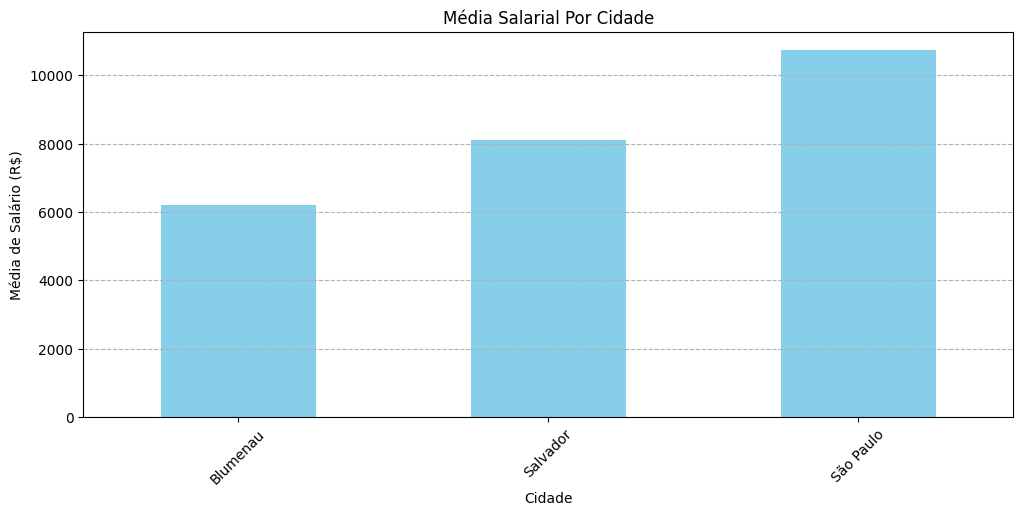

In [117]:
# Gráfico de Barras: Média de Salário por Cidade
media_salario_cidade.plot(kind = 'bar', figsize = (12, 5), color = 'skyblue')

# Adicionando títulos e rótulos
plt.title('Média Salarial Por Cidade')
plt.xlabel('Cidade')
plt.ylabel('Média de Salário (R$)')
plt.xticks(rotation = 45) 
plt.grid(axis = 'y', linestyle = '--')

# Mostra o gráfico
plt.show()

In [118]:
# Contagem de registros (funcionários) por cidade
contagem_cidade = df_dsa['Cidade'].value_counts()

In [119]:
type(contagem_cidade)

pandas.Series

In [120]:
contagem_cidade

Cidade
São Paulo    3
Blumenau     2
Salvador     1
Name: count, dtype: int64

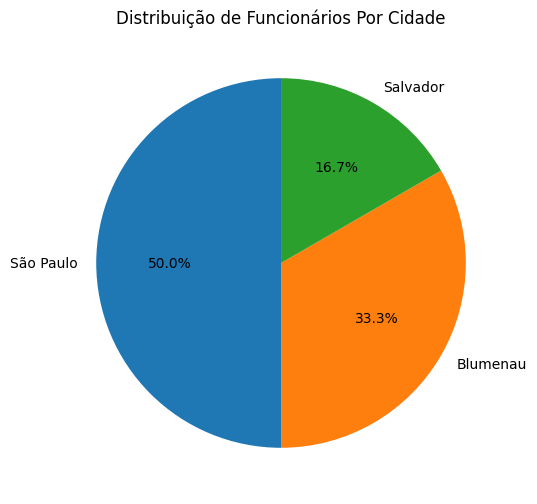

In [121]:
# Gráfico de Pizza: Contagem de funcionários por cidade
contagem_cidade.plot(kind = 'pie', autopct = '%1.1f%%', figsize = (6, 6), startangle = 90)
plt.title('Distribuição de Funcionários Por Cidade')
plt.ylabel('') # Remove o rótulo do eixo y
plt.show()